# FRAMES — Execution-Trace Statistics & Semantic–Execution Correlation

Analysis of the FRAMES execution traces, combining **`traces/claude_native/frames_kb`**
and **`traces/claude_native/frames_test`** into one corpus (no KB/test split — this is a
general benchmark-wide semantic-vs-execution study). FRAMES queries are naturally diverse
and large-scale (~800 real multi-hop questions), so — unlike GAIA — we do **not** need
synthesized paraphrases and there is **no within-group / global comparison**.

Query embeddings are the pre-computed 768-d `all-mpnet-base-v2` vectors under
`embeddings/claude_native/{frames_kb,frames_test}/`.

Sections:
1. Scalar summary stats (step count / tokens / latency)
2. Tool-call frequency distribution
3. Top-10 tool sequences
4. Top-10 tool transitions (A → B)
5. Semantic diversity — distribution of pairwise embedding similarity
6. Embedding similarity vs tool-representation similarity (all pairs)
7. Which structural metric is most correlated with semantic similarity (15 metrics)


In [1]:
%matplotlib inline
from pathlib import Path
import json, re
from collections import Counter, defaultdict
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

pd.set_option("display.width", 140); pd.set_option("display.max_columns", 40)

EKB_ROOT = Path.cwd()
if not (EKB_ROOT / "traces").exists() and (EKB_ROOT.parent / "traces").exists():
    EKB_ROOT = EKB_ROOT.parent
RUNS = ["frames_kb", "frames_test"]
NPAIRS = 60000          # sampled pairs for the (expensive) pairwise structural metrics
print("EKB_ROOT:", EKB_ROOT, "| runs:", RUNS)


EKB_ROOT: /Users/tungi/ekb-claude-pilot | runs: ['frames_kb', 'frames_test']


In [2]:
# ---- Load normalized traces from both runs ----
rows = []
for run in RUNS:
    tdir_root = EKB_ROOT / "traces" / "claude_native" / run
    for tdir in sorted(tdir_root.glob("*")):
        f = tdir / "normalized_trace.json"
        if not f.exists():
            continue
        t = json.loads(f.read_text())
        seq = [s["tool"] for s in (t.get("steps") or []) if s.get("tool")]
        rows.append(dict(
            task_id=t["query_id"], emb_run=run,
            total_steps=t.get("total_steps"),
            total_tokens=t.get("total_tokens"),
            total_latency_ms=t.get("total_latency_ms"),
            latency_s=(t.get("total_latency_ms") or np.nan) / 1000.0,
            tools_used=tuple(sorted(set(seq))),
            tool_sequence=tuple(seq),
            has_answer=bool(t.get("final_answer_pred") and str(t.get("final_answer_pred")).strip()),
            exact_match=t.get("exact_match"),
        ))
df = pd.DataFrame(rows).drop_duplicates("task_id").reset_index(drop=True)
print(f"{len(df)} traces total | by run: {df.emb_run.value_counts().to_dict()} | "
      f"{df.has_answer.sum()} with answer")
df.head(3)


823 traces total | by run: {'frames_kb': 626, 'frames_test': 197} | 819 with answer


,task_id,emb_run,total_steps,total_tokens,total_latency_ms,latency_s,tools_used,tool_sequence,has_answer,exact_match
0,frames_test_00000,frames_kb,6,138928,36962,36.962,"(StructuredOutput, ToolSearch, WebSearch)","(ToolSearch, WebSearch, WebSearch, WebSearch, ...",True,True
1,frames_test_00001,frames_kb,43,1828574,816209,816.209,"(StructuredOutput, ToolSearch, WebFetch, WebSe...","(ToolSearch, WebSearch, WebSearch, WebSearch, ...",True,True
2,frames_test_00002,frames_kb,5,141057,49172,49.172,"(StructuredOutput, ToolSearch, WebSearch)","(ToolSearch, WebSearch, WebSearch, WebSearch, ...",True,True


## 1. Scalar summary stats — step count / token use / latency

,n,mean,median,p75,max,min,std
step_count,823.0,7.13,5.00,8.00,72.00,1.00,6.51
total_tokens,823.0,221242.14,163528.00,223752.50,2196823.00,51188.00,226034.93
latency_s,823.0,66.30,40.54,62.94,816.21,6.81,86.30


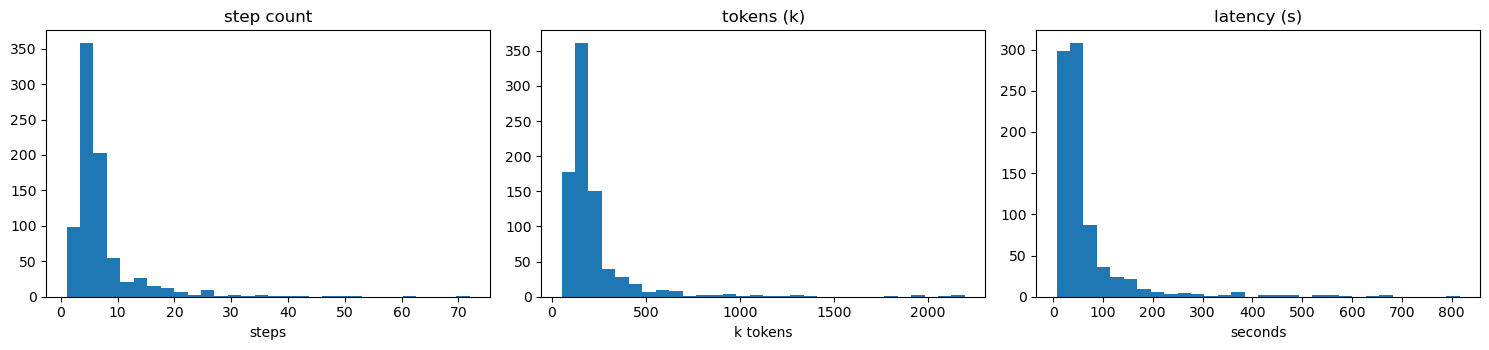

In [3]:
def summarize(s):
    s = pd.Series(s).dropna()
    return dict(n=len(s), mean=s.mean(), median=s.median(),
                p75=s.quantile(0.75), max=s.max(), min=s.min(), std=s.std())
summary = pd.DataFrame({
    "step_count":   summarize(df.total_steps),
    "total_tokens": summarize(df.total_tokens),
    "latency_s":    summarize(df.latency_s),
}).T[["n", "mean", "median", "p75", "max", "min", "std"]]
display(summary.round(2))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].hist(df.total_steps.dropna(), bins=30);       ax[0].set_title("step count");  ax[0].set_xlabel("steps")
ax[1].hist(df.total_tokens.dropna()/1000, bins=30); ax[1].set_title("tokens (k)");  ax[1].set_xlabel("k tokens")
ax[2].hist(df.latency_s.dropna(), bins=30);         ax[2].set_title("latency (s)"); ax[2].set_xlabel("seconds")
plt.tight_layout(); plt.show()


## 2. Tool-call frequency distribution

,tool,calls,pct_of_calls,n_tasks_using,pct_tasks
0,WebSearch,2533,43.1,801,97.3
1,WebFetch,1333,22.7,329,40.0
2,ToolSearch,1094,18.6,804,97.7
3,StructuredOutput,823,14.0,820,99.6
4,Bash,88,1.5,79,9.6


MOST frequent : WebSearch (2533)  |  LEAST frequent: Bash (88)


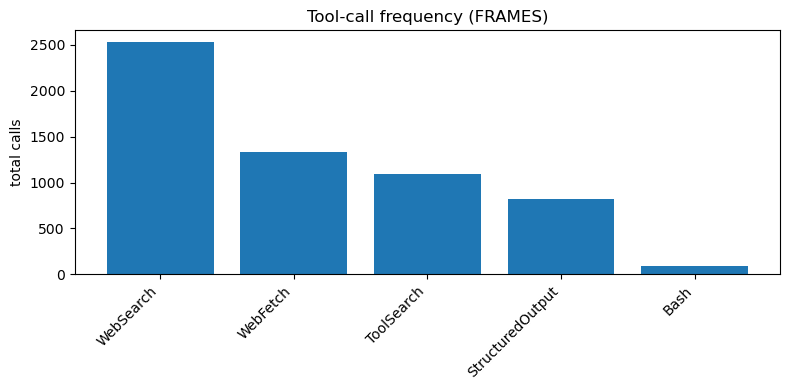

In [4]:
tool_calls = Counter()
for seq in df.tool_sequence: tool_calls.update(seq)
tasks_using = Counter()
for tu in df.tools_used: tasks_using.update(tu)
freq = (pd.DataFrame([{"tool": k, "calls": v} for k, v in tool_calls.items()])
        .sort_values("calls", ascending=False).reset_index(drop=True))
freq["pct_of_calls"]  = (freq.calls / freq.calls.sum() * 100).round(1)
freq["n_tasks_using"] = freq.tool.map(tasks_using)
freq["pct_tasks"]     = (freq.n_tasks_using / len(df) * 100).round(1)
display(freq)
print(f"MOST frequent : {freq.iloc[0].tool} ({freq.iloc[0].calls})  |  "
      f"LEAST frequent: {freq.iloc[-1].tool} ({freq.iloc[-1].calls})")
plt.figure(figsize=(8, 4)); plt.bar(freq.tool, freq.calls)
plt.xticks(rotation=45, ha="right"); plt.ylabel("total calls"); plt.title("Tool-call frequency (FRAMES)")
plt.tight_layout(); plt.show()


## 3. Top-10 most frequent tool sequences

In [5]:
seq_counter = Counter(df.tool_sequence)
top_seq = pd.DataFrame(
    [{"rank": i+1, "count": c, "len": len(s), "sequence": " → ".join(s) if s else "(empty)"}
     for i, (s, c) in enumerate(seq_counter.most_common(10))])
display(top_seq)
print(f"{len(seq_counter)} distinct tool sequences across {len(df)} traces")


,rank,count,len,sequence
0,1,213,4,ToolSearch → WebSearch → WebSearch → Structure...
1,2,111,5,ToolSearch → WebSearch → WebSearch → WebSearch...
2,3,78,3,ToolSearch → WebSearch → StructuredOutput
3,4,32,6,ToolSearch → WebSearch → WebSearch → ToolSearc...
4,5,25,6,ToolSearch → WebSearch → WebSearch → WebSearch...
5,6,18,1,StructuredOutput
6,7,17,7,ToolSearch → WebSearch → WebSearch → ToolSearc...
7,8,15,5,ToolSearch → WebSearch → WebSearch → Bash → St...
8,9,10,6,ToolSearch → WebSearch → ToolSearch → WebFetch...
9,10,10,8,ToolSearch → WebSearch → WebSearch → WebSearch...


214 distinct tool sequences across 823 traces


## 4. Top-10 most frequent tool transitions (A → B)

In [6]:
trans = Counter()
for seq in df.tool_sequence:
    for a, b in zip(seq, seq[1:]): trans[(a, b)] += 1
top_trans = pd.DataFrame(
    [{"rank": i+1, "transition": f"{a} → {b}", "count": c}
     for i, ((a, b), c) in enumerate(trans.most_common(10))])
display(top_trans)
print(f"{len(trans)} distinct transitions; {sum(trans.values())} total")


,rank,transition,count
0,1,WebSearch → WebSearch,1220
1,2,ToolSearch → WebSearch,812
2,3,WebFetch → WebFetch,609
3,4,WebSearch → StructuredOutput,534
4,5,WebFetch → WebSearch,498
5,6,WebSearch → WebFetch,441
6,7,WebSearch → ToolSearch,290
7,8,ToolSearch → WebFetch,279
8,9,WebFetch → StructuredOutput,187
9,10,Bash → StructuredOutput,79


19 distinct transitions; 5048 total


## Load query embeddings (pre-computed, 768-d all-mpnet-base-v2)

In [7]:
emb = {}
for _, r in df.iterrows():
    p = EKB_ROOT / "embeddings" / "claude_native" / r.emb_run / r.task_id / "query_embedding.npy"
    if p.exists():
        emb[r.task_id] = np.load(p).astype(np.float64)
dfe = df[df.task_id.isin(emb)].reset_index(drop=True)
E = np.stack([emb[t] for t in dfe.task_id])
E = E / np.linalg.norm(E, axis=1, keepdims=True)
n = len(dfe)
print(f"{n}/{len(df)} traces have embeddings | matrix {E.shape}")


823/823 traces have embeddings | matrix (823, 768)


## 5. Semantic diversity — distribution of pairwise embedding similarity
Without paraphrases, this shows how semantically spread the FRAMES corpus is (all
C(n,2) pairs). A low, tight distribution ⇒ genuinely diverse queries (good for a
representative semantic–execution study).

all pairs: 338,253 | mean=0.147 median=0.137 p95=0.330 max=0.976


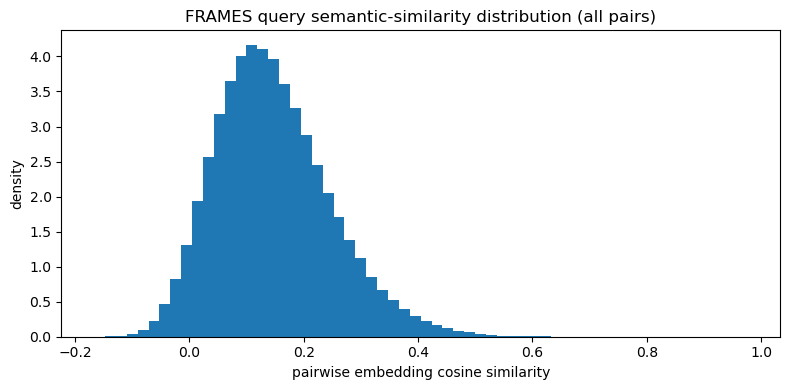

In [8]:
iu = np.triu_indices(n, k=1)
emb_all = (E @ E.T)[iu]
print(f"all pairs: {len(emb_all):,} | mean={emb_all.mean():.3f} median={np.median(emb_all):.3f} "
      f"p95={np.quantile(emb_all,0.95):.3f} max={emb_all.max():.3f}")
plt.figure(figsize=(8, 4)); plt.hist(emb_all, bins=60, density=True)
plt.xlabel("pairwise embedding cosine similarity"); plt.ylabel("density")
plt.title("FRAMES query semantic-similarity distribution (all pairs)")
plt.tight_layout(); plt.show()


## 6. Embedding similarity vs tool-representation similarity
For a random sample of query pairs we correlate embedding cosine similarity with the
similarity of four execution representations (one per trace feature): tool **set**
(binary cosine), tool **count** (cosine), tool **transition** (bigram cosine), and tool
**sequence** (`difflib` ratio). Positive correlation ⇒ semantically similar queries
execute more alike.

using 60,000 sampled pairs (of 338,253 total)
Pearson / Spearman correlation with embedding similarity:
  toolset_binary_cos  : r = +0.001   rho = -0.002
  toolcount_cos       : r = +0.002   rho = +0.013
  transition_cos      : r = +0.020   rho = +0.022
  seq_ratio           : r = +0.003   rho = +0.003


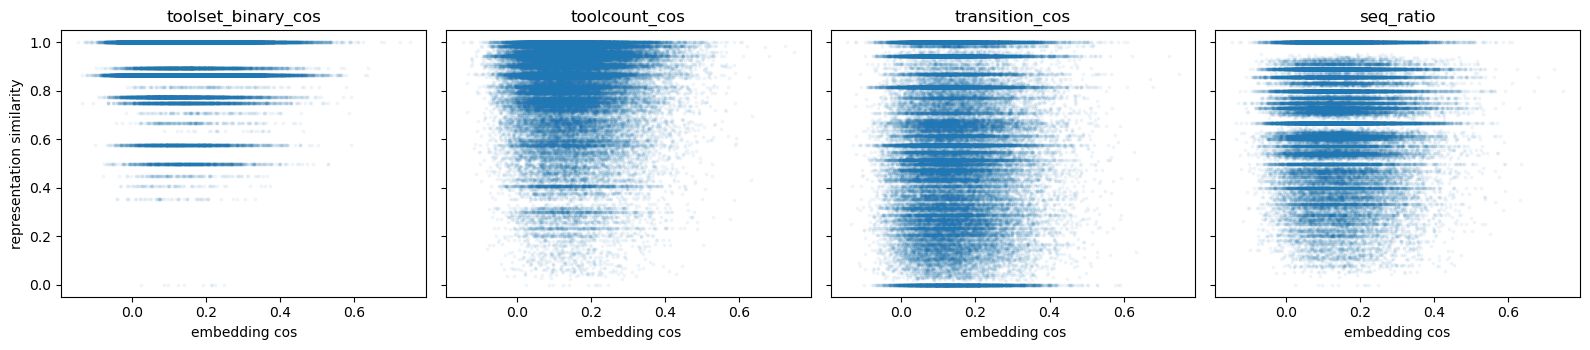

In [9]:
rng = np.random.default_rng(0)
total_pairs = n * (n - 1) // 2
if total_pairs <= NPAIRS:
    PI, PJ = (np.array(x) for x in zip(*[(i, j) for i in range(n) for j in range(i+1, n)]))
else:
    m = NPAIRS * 3
    ii = rng.integers(0, n, m); jj = rng.integers(0, n, m)
    k = ii < jj
    uniq = list(dict.fromkeys(zip(ii[k].tolist(), jj[k].tolist())))[:NPAIRS]
    PI, PJ = np.array([a for a, _ in uniq]), np.array([b for _, b in uniq])
print(f"using {len(PI):,} sampled pairs (of {total_pairs:,} total)")

# per-trace tool representations
vocab = sorted({t for s in dfe.tool_sequence for t in s})
vidx = {t: i for i, t in enumerate(vocab)}
def binvec(s):
    v = np.zeros(len(vocab));  [v.__setitem__(vidx[t], 1) for t in set(s)];  return v
def countvec(s):
    v = np.zeros(len(vocab))
    for t in s: v[vidx[t]] += 1
    return v
def cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na > 0 and nb > 0 else 0.0
seqs = list(dfe.tool_sequence)
B = np.stack([binvec(s) for s in seqs]); C = np.stack([countvec(s) for s in seqs])
bv = sorted({(a, b) for s in seqs for a, b in zip(s, s[1:])}); bi = {g: i for i, g in enumerate(bv)}
def transvec(s):
    v = np.zeros(max(len(bv), 1))
    for a, b in zip(s, s[1:]): v[bi[(a, b)]] += 1
    return v
Tr = np.stack([transvec(s) for s in seqs])
Eu = E  # already normalized

emb_sim = (Eu[PI] * Eu[PJ]).sum(1)
P = pd.DataFrame({
    "emb_sim": emb_sim,
    "toolset_binary_cos": [cos(B[i], B[j]) for i, j in zip(PI, PJ)],
    "toolcount_cos":      [cos(C[i], C[j]) for i, j in zip(PI, PJ)],
    "transition_cos":     [cos(Tr[i], Tr[j]) for i, j in zip(PI, PJ)],
    "seq_ratio":          [SequenceMatcher(None, seqs[i], seqs[j]).ratio() for i, j in zip(PI, PJ)],
})
print("Pearson / Spearman correlation with embedding similarity:")
for rep in ["toolset_binary_cos", "toolcount_cos", "transition_cos", "seq_ratio"]:
    print(f"  {rep:20s}: r = {pearsonr(P.emb_sim, P[rep])[0]:+.3f}   "
          f"rho = {spearmanr(P.emb_sim, P[rep])[0]:+.3f}")

fig, ax = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for k, rep in enumerate(["toolset_binary_cos", "toolcount_cos", "transition_cos", "seq_ratio"]):
    ax[k].scatter(P.emb_sim, P[rep], s=3, alpha=0.05)
    ax[k].set_title(rep); ax[k].set_xlabel("embedding cos")
ax[0].set_ylabel("representation similarity")
plt.tight_layout(); plt.show()


## 7. Which structural metric is most correlated with semantic similarity?
We correlate 15 pairwise structural similarities against embedding cosine similarity
(Pearson + Spearman, on the sampled pairs). Each metric targets one **trace feature** —
tool **set**, tool **count**, tool **transition**, tool **sequence** (bars colored by feature).

**Notation.** For two traces $a,b$ over tool vocabulary $V$:
$S_x$ = set of tools used; $\mathbf{c}_x\in\mathbb{Z}_{\ge 0}^{|V|}$ = tool-count vector;
$\mathbf{u}_x\in\{0,1\}^{|V|}$ = binary used-tool vector; $\mathbf{t}_x$ = transition (A→B
bigram) count vector with transition set $\mathcal{T}_x$; $\sigma_x$ = ordered tool
sequence. Primed symbols are **substantive** versions (scaffolding tools
$\{$ToolSearch, StructuredOutput$\}$ removed).
$\cos(\mathbf{x},\mathbf{y})=\dfrac{\mathbf{x}\cdot\mathbf{y}}{\lVert\mathbf{x}\rVert\,\lVert\mathbf{y}\rVert}$,
$\;J(A,B)=\dfrac{|A\cap B|}{|A\cup B|}$.

**Tool set** — `toolset_jaccard` $=J(S_a,S_b)$; `toolset_binary_cosine` $=\cos(\mathbf{u}_a,\mathbf{u}_b)$;
`toolset_jaccard_substantive` $=J(S'_a,S'_b)$.
**Tool count** — `toolcount_cosine` $=\cos(\mathbf{c}_a,\mathbf{c}_b)$;
`toolcount_manhattan` $=\dfrac{1}{1+\lVert\mathbf{c}_a-\mathbf{c}_b\rVert_1}$;
`toolcount_tfidf_cosine` $=\cos(\mathbf{c}_a\odot\boldsymbol{\phi},\mathbf{c}_b\odot\boldsymbol{\phi}),\;\phi_v=\ln\frac{N+1}{\mathrm{df}_v+1}+1$;
`toolcount_weighted_jaccard` $=\dfrac{\sum_v\min(c_{a,v},c_{b,v})}{\sum_v\max(c_{a,v},c_{b,v})}$;
`toolcount_braycurtis` $=1-\dfrac{\sum_v|c_{a,v}-c_{b,v}|}{\sum_v(c_{a,v}+c_{b,v})}$.
**Tool transition** — `sequence_transition_cosine` $=\cos(\mathbf{t}_a,\mathbf{t}_b)$;
`transition_jaccard` $=J(\mathcal{T}_a,\mathcal{T}_b)$; `transition_cosine_substantive` $=\cos(\mathbf{t}'_a,\mathbf{t}'_b)$.
**Tool sequence** — `sequence_levenshtein` $=1-\dfrac{\mathrm{lev}(\sigma_a,\sigma_b)}{\max(|\sigma_a|,|\sigma_b|)}$;
`seq_levenshtein_substantive` (same on $\sigma'$); `seq_lcs_ratio` $=\dfrac{2\,\mathrm{LCS}}{|\sigma_a|+|\sigma_b|}$;
`seq_ratio_difflib` $=\dfrac{2M}{|\sigma_a|+|\sigma_b|}$ (Ratcliff–Obershelp).

,metric,family,pearson_r,spearman_r,original
0,transition_cosine_substantive,tool transition,0.048,0.048,False
1,sequence_transition_cosine,tool transition,0.020,0.022,True
2,transition_jaccard,tool transition,0.019,0.019,False
3,seq_levenshtein_substantive,tool sequence,0.016,0.016,False
4,sequence_levenshtein,tool sequence,0.008,0.007,True
5,toolcount_weighted_jaccard,tool count,0.007,0.005,False
6,toolcount_braycurtis,tool count,0.005,0.005,False
7,seq_lcs_ratio,tool sequence,0.004,0.004,False
8,toolcount_tfidf_cosine,tool count,0.004,0.007,False
9,toolset_jaccard_substantive,tool set,0.003,0.005,False



Best indicator: transition_cosine_substantive  [tool transition]  (Pearson r = 0.048, Spearman = 0.048)
Best per trace feature:
  tool set        : toolset_jaccard_substantive      r = 0.003
  tool count      : toolcount_weighted_jaccard       r = 0.007
  tool transition : transition_cosine_substantive    r = 0.048
  tool sequence   : seq_levenshtein_substantive      r = 0.016


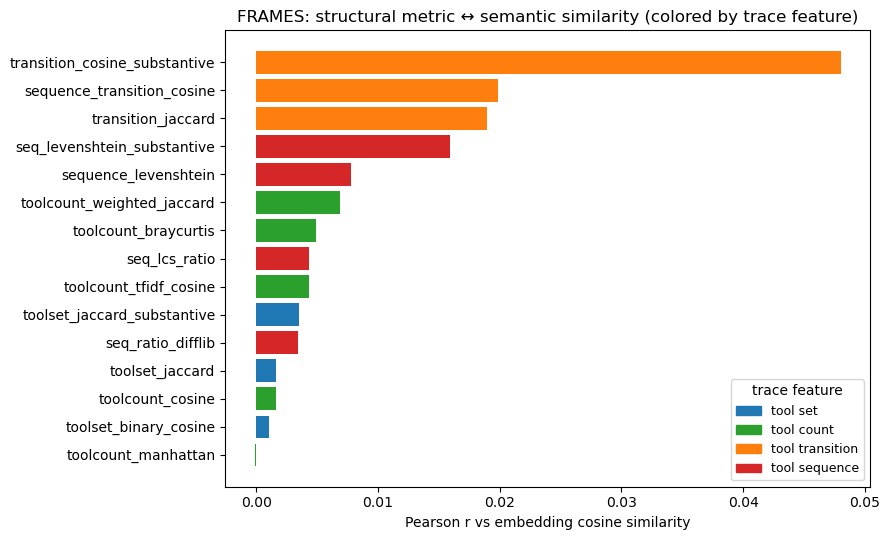

In [10]:
OVERHEAD = {"ToolSearch", "StructuredOutput"}
sets = [set(s) for s in seqs]
sub_seqs = [tuple(t for t in s if t not in OVERHEAD) for s in seqs]
sub_sets = [set(s) for s in sub_seqs]
trans_sets = [set(zip(s, s[1:])) for s in seqs]
Ntr = len(dfe); dftool = Counter()
for s in seqs: dftool.update(set(s))
idf = np.array([np.log((Ntr + 1) / (dftool[t] + 1)) + 1 for t in vocab]); TF = C * idf
def make_trans(seq_list):
    bb = sorted({(a, b) for s in seq_list for a, b in zip(s, s[1:])}); bj = {g: i for i, g in enumerate(bb)}
    M = np.zeros((len(seq_list), max(len(bb), 1)))
    for r, s in enumerate(seq_list):
        for a, b in zip(s, s[1:]): M[r, bj[(a, b)]] += 1
    return M
T, SUBT = make_trans(seqs), make_trans(sub_seqs)
def jaccard(a, b):
    if not a and not b: return 1.0
    u = len(a | b); return len(a & b) / u if u else 0.0
def levenshtein(a, b):
    m, k = len(a), len(b)
    if m == 0 or k == 0: return max(m, k)
    prev = list(range(k + 1))
    for i in range(1, m + 1):
        cur = [i] + [0] * k
        for j in range(1, k + 1):
            cur[j] = min(prev[j] + 1, cur[j-1] + 1, prev[j-1] + (a[i-1] != b[j-1]))
        prev = cur
    return prev[k]
def lev_sim(a, b):
    ml = max(len(a), len(b)); return 1 - levenshtein(a, b) / ml if ml else 1.0
def lcs_sim(a, b):
    la, lb = len(a), len(b)
    if la == 0 or lb == 0: return 1.0 if la == lb else 0.0
    prev = [0] * (lb + 1)
    for i in range(1, la + 1):
        cur = [0] * (lb + 1)
        for j in range(1, lb + 1):
            cur[j] = prev[j-1] + 1 if a[i-1] == b[j-1] else max(prev[j], cur[j-1])
        prev = cur
    return 2 * prev[lb] / (la + lb)
def wjac(a, b):
    mn, mx = np.minimum(a, b).sum(), np.maximum(a, b).sum(); return float(mn / mx) if mx > 0 else 1.0
def bray(a, b):
    d = (a + b).sum(); return 1 - float(np.abs(a - b).sum()) / d if d > 0 else 1.0

ORIG = {"sequence_transition_cosine", "toolset_jaccard", "toolcount_cosine",
        "toolset_binary_cosine", "sequence_levenshtein", "toolcount_manhattan"}
metrics = {
    "sequence_transition_cosine":    lambda i, j: cos(T[i], T[j]),
    "toolset_jaccard":               lambda i, j: jaccard(sets[i], sets[j]),
    "toolcount_cosine":              lambda i, j: cos(C[i], C[j]),
    "toolset_binary_cosine":         lambda i, j: cos(B[i], B[j]),
    "sequence_levenshtein":          lambda i, j: lev_sim(seqs[i], seqs[j]),
    "toolcount_manhattan":           lambda i, j: 1.0 / (1.0 + float(np.abs(C[i] - C[j]).sum())),
    "seq_ratio_difflib":             lambda i, j: SequenceMatcher(None, seqs[i], seqs[j]).ratio(),
    "seq_lcs_ratio":                 lambda i, j: lcs_sim(seqs[i], seqs[j]),
    "transition_jaccard":            lambda i, j: jaccard(trans_sets[i], trans_sets[j]),
    "toolcount_tfidf_cosine":        lambda i, j: cos(TF[i], TF[j]),
    "toolcount_weighted_jaccard":    lambda i, j: wjac(C[i], C[j]),
    "toolcount_braycurtis":          lambda i, j: bray(C[i], C[j]),
    "toolset_jaccard_substantive":   lambda i, j: jaccard(sub_sets[i], sub_sets[j]),
    "seq_levenshtein_substantive":   lambda i, j: lev_sim(sub_seqs[i], sub_seqs[j]),
    "transition_cosine_substantive": lambda i, j: cos(SUBT[i], SUBT[j]),
}
vals = {k: [] for k in metrics}
for i, j in zip(PI, PJ):
    for k, fn in metrics.items(): vals[k].append(fn(i, j))
ep = emb_sim  # from section 6, same sampled pairs

FAMILY = {"toolset_jaccard": "tool set", "toolset_binary_cosine": "tool set",
          "toolset_jaccard_substantive": "tool set",
          "toolcount_cosine": "tool count", "toolcount_manhattan": "tool count",
          "toolcount_tfidf_cosine": "tool count", "toolcount_weighted_jaccard": "tool count",
          "toolcount_braycurtis": "tool count",
          "sequence_transition_cosine": "tool transition", "transition_jaccard": "tool transition",
          "transition_cosine_substantive": "tool transition",
          "sequence_levenshtein": "tool sequence", "seq_ratio_difflib": "tool sequence",
          "seq_lcs_ratio": "tool sequence", "seq_levenshtein_substantive": "tool sequence"}
FCOLOR = {"tool set": "tab:blue", "tool count": "tab:green",
          "tool transition": "tab:orange", "tool sequence": "tab:red"}
res = pd.DataFrame([
    dict(metric=k, family=FAMILY[k], pearson_r=pearsonr(ep, np.array(v))[0],
         spearman_r=spearmanr(ep, np.array(v))[0], original=(k in ORIG))
    for k, v in vals.items()
]).sort_values("pearson_r", ascending=False).reset_index(drop=True)
display(res.round(3))
b = res.iloc[0]
print(f"\nBest indicator: {b.metric}  [{b.family}]  (Pearson r = {b.pearson_r:.3f}, Spearman = {b.spearman_r:.3f})")
print("Best per trace feature:")
for fam in ["tool set", "tool count", "tool transition", "tool sequence"]:
    sub = res[res.family == fam].iloc[0]
    print(f"  {fam:16s}: {sub.metric:32s} r = {sub.pearson_r:.3f}")

plt.figure(figsize=(9, 5.5)); order = res[::-1]
plt.barh(order.metric, order.pearson_r, color=[FCOLOR[f] for f in order.family])
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color=c, label=f) for f, c in FCOLOR.items()],
           loc="lower right", fontsize=9, title="trace feature")
plt.xlabel("Pearson r vs embedding cosine similarity")
plt.title("FRAMES: structural metric ↔ semantic similarity (colored by trace feature)")
plt.tight_layout(); plt.show()
